# Step 5 Modeling - Logistic Regression & Random Forest


**Created/Updated by:** Thiri

**Goal:** Predict `Depression_Flag` (PHQ-9 >= 10) from demographic, socioeconomic and lifestyle
features only. PHQ-9 itself was already dropped in Step 4 to prevent target leakage.


1. Loads the pre-built train / validation / test splits from Step 3.
2. Removes the survey-design column and redundant duplicate features.
3. Trains a **Logistic Regression** (interpretable baseline) on the standardized split.
4. Trains a **Random Forest** (non-linear baseline) on the one-hot split.
5. Tunes both on the **validation** set, then scores the winners **once** on test.
6. Saves a shared scoreboard CSV so CatBoost / XGBoost / SVM can be appended later.

**Why the metrics are ordered PR-AUC first:** only ~10.6% of rows are positive.
A model that predicts "not depressed" for everyone already scores 89% accuracy,
so accuracy alone would hide a useless model.

### Imports Libries

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

### Configurations

In [2]:
# Folder layout - adjust BASE_DIR only if the notebook is moved out of the project root
BASE_DIR   = "."
SPLIT_DIR  = os.path.join(BASE_DIR, "DataSplit")
MODEL_DIR  = os.path.join(BASE_DIR, "Models")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")

# Create output folders if they are not there yet
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# One seed for every model so results are reproducible and comparable
RANDOM_STATE = 42

# File name stems for the two encodings this notebook needs
STD_STEM  = "Nhanes_SVM_Logistic"   # one-hot + standardized -> Logistic Regression
TREE_STEM = "Nhanes_XGB_Forest"     # one-hot only           -> Random Forest
TARGET_STEM = "Nhanes_Target"       # the y vector, shared by every model

# Shared scoreboard file - CatBoost / XGBoost / SVM notebooks append to this same file
SCOREBOARD_CSV = os.path.join(MODEL_DIR, "rf_logreg_models_scoreboard.csv")

#### Load the splits

Step 4 already produced matched train / validation / test files, so no re-splitting happens here.
Re-splitting would break comparability with the other four models.

In [3]:
# Read one feature file for a given encoding stem and split name
def load_features(stem, split):
    path = os.path.join(SPLIT_DIR, f"{stem}_{split}.csv")
    return pd.read_csv(path, low_memory=False)


# Read the target file for a split and return it as a flat 1-D array
def load_target(split):
    path = os.path.join(SPLIT_DIR, f"{TARGET_STEM}_{split}.csv")
    return pd.read_csv(path)["Depression_Flag"].to_numpy()


# Load the three target vectors once - they are shared by both models
y_train = load_target("Train")
y_val   = load_target("Val")
y_test  = load_target("Test")

# Quick sanity check on class balance in every split
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:<6} n={len(y):>6}  positives={y.sum():>5}  rate={y.mean():.4f}")

Train  n=  9611  positives= 1020  rate=0.1061
Val    n=  2060  positives=  235  rate=0.1141
Test   n=  2060  positives=  235  rate=0.1141


#### Remove leakage-adjacent and redundant columns

Two clean-up jobs before modeling:

WTMEC_COMB is a survey weight, not a predictor.** It encodes how NHANES sampled the
respondent. Leaving it in lets the trees split on sampling design, which produces feature
importances that mean nothing clinically.

Duplicate-information columns.These inflate Logistic Regression standard errors and
split Random Forest importance across twin columns.

Drop - RIDRETH1 Same race/ethnicity variable, RETH3 is the finer recode 

Drop -INDFMMPI and  INDFMMPC, All three are poverty-income ratio variants 

Drop - ALQ142  measure drinking frequency 


In [4]:
# Columns dropped by exact name
DROP_EXACT = ["WTMEC_COMB"]

# Columns dropped by prefix, because one-hot encoding turned each one into many dummy columns
DROP_PREFIX = ["RIDRETH1_", "INDFMMPI", "INDFMMPC_", "ALQ142_"]


# Return a copy of the dataframe with the survey weight and redundant features removed
def drop_unwanted_columns(df):
    to_drop = [c for c in df.columns if c in DROP_EXACT]
    to_drop += [c for c in df.columns if any(c.startswith(p) for p in DROP_PREFIX)]
    return df.drop(columns=sorted(set(to_drop)))


# Load an encoding stem for all three splits and apply the same column clean-up to each
def load_clean_split(stem):
    train = drop_unwanted_columns(load_features(stem, "Train"))
    val   = drop_unwanted_columns(load_features(stem, "Val"))
    test  = drop_unwanted_columns(load_features(stem, "Test"))

    # Guard: all three splits must end up with identical columns in identical order
    if not (list(train.columns) == list(val.columns) == list(test.columns)):
        raise ValueError(f"Column mismatch across splits for {stem}")

    return train, val, test


# Standardized data for Logistic Regression
X_train_std, X_val_std, X_test_std = load_clean_split(STD_STEM)

# One-hot only data for Random Forest
X_train_tree, X_val_tree, X_test_tree = load_clean_split(TREE_STEM)

print(f"Logistic  features: {X_train_std.shape[1]}")
print(f"Forest    features: {X_train_tree.shape[1]}")
print(f"Dropped:  {sorted(set(load_features(STD_STEM, 'Train').columns) - set(X_train_std.columns))}")

print(X_train_std.shape, X_train_tree.shape)

Logistic  features: 54
Forest    features: 54
Dropped:  ['ALQ142_-1.0', 'ALQ142_0.0', 'ALQ142_1.0', 'ALQ142_10.0', 'ALQ142_2.0', 'ALQ142_3.0', 'ALQ142_4.0', 'ALQ142_5.0', 'ALQ142_6.0', 'ALQ142_7.0', 'ALQ142_8.0', 'ALQ142_9.0', 'INDFMMPC_-1.0', 'INDFMMPC_1.0', 'INDFMMPC_2.0', 'INDFMMPC_3.0', 'INDFMMPI', 'RIDRETH1_1.0', 'RIDRETH1_2.0', 'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0', 'WTMEC_COMB']
(9611, 54) (9611, 54)


#### Shared evaluation helpers

Every model in the project goes through these two helpers, so the comparison table is
apples-to-apples. The `Scoreboard` class is the only class in this notebook - it exists purely
to hold results and write them to one shared CSV.

In [5]:
# Score a fitted model on one dataset and return a single row of metrics
def score_model(model, X, y, threshold=0.5):
    # Predicted probability of the positive class
    proba = model.predict_proba(X)[:, 1]

    # Hard labels using the chosen decision threshold
    pred = (proba >= threshold).astype(int)

    return {
        "PR_AUC":    average_precision_score(y, proba),
        "ROC_AUC":   roc_auc_score(y, proba),
        "Recall":    recall_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "Accuracy":  accuracy_score(y, pred),
        "Threshold": threshold,
    }


# Collects metric rows from every model so the team can compare them in one table
class Scoreboard:

    # Start an empty results list
    def __init__(self):
        self._rows = []

    # Record one result row, tagged with the model name and which split it came from
    def add(self, model_name, split, metrics):
        if not model_name:
            raise ValueError("model_name is required")
        row = {"Model": model_name, "Split": split}
        row.update(metrics)
        self._rows.append(row)

    # Return the collected results as a dataframe sorted by PR-AUC
    def to_frame(self):
        if not self._rows:
            raise ValueError("Scoreboard is empty - add results before exporting")
        return pd.DataFrame(self._rows).sort_values(
            ["Split", "PR_AUC"], ascending=[True, False]
        ).reset_index(drop=True)

    # Append the results to the shared project CSV, replacing this notebook's own old rows
    def save(self, path):
        new = self.to_frame()
        if os.path.exists(path):
            old = pd.read_csv(path)
            old = old[~old["Model"].isin(new["Model"].unique())]
            new = pd.concat([old, new], ignore_index=True)
        new.to_csv(path, index=False)
        return new


# One scoreboard instance for this notebook
board = Scoreboard()

####  Modeling - Logistic Regression

Uses the standardized split. This is the interpretable baseline every other model must beat.

- `class_weight="balanced"` offsets the 10.6% positive rate.
- `penalty="l2"` keeps coefficients stable given the correlated one-hot dummies.
- We tune `C` (the inverse regularization strength) on the validation set only.

In [6]:
# Candidate regularization strengths, weak to strong
C_GRID = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

# Build a Logistic Regression with the project's fixed settings
def build_logistic(C):
    return LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )


# Fit one model per C value and record its validation PR-AUC
logistic_search = []
for C in C_GRID:
    model = build_logistic(C).fit(X_train_std, y_train)
    metrics = score_model(model, X_val_std, y_val)
    logistic_search.append({"C": C, **metrics})

logistic_search_df = pd.DataFrame(logistic_search)
display(logistic_search_df.round(4))

# Pick the C with the best validation PR-AUC
best_C = logistic_search_df.loc[logistic_search_df["PR_AUC"].idxmax(), "C"]
print(f"\nBest C by validation PR-AUC: {best_C}")

,C,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,0.01,0.2342,0.7036,0.6468,0.1977,0.3028,0.6602,0.5
1,0.05,0.2342,0.7040,0.6426,0.1979,0.3026,0.6621,0.5
2,0.10,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5
3,0.50,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5
4,1.00,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5
5,5.00,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5



Best C by validation PR-AUC: 5.0


In [7]:
# Refit the winning Logistic Regression on the training data
logistic_model = build_logistic(best_C).fit(X_train_std, y_train)

# Record its validation performance on the shared scoreboard
logistic_val = score_model(logistic_model, X_val_std, y_val)
board.add("LogisticRegression", "Validation", logistic_val)

print("Logistic Regression - validation")
for k, v in logistic_val.items():
    print(f"  {k:<10} {v:.4f}")

Logistic Regression - validation
  PR_AUC     0.2342
  ROC_AUC    0.7041
  Recall     0.6426
  Precision  0.1979
  F1         0.3026
  Accuracy   0.6621
  Threshold  0.5000


#### Which factors drive the prediction?

Because the features were standardized, the coefficients are directly comparable.
Exponentiating a coefficient gives the odds ratio: how much the odds of screening
positive change per one standard deviation increase in that feature.

In [8]:
# Turn the fitted coefficients into a readable odds-ratio table
coefficients = pd.DataFrame({
    "Feature": X_train_std.columns,
    "Coefficient": logistic_model.coef_[0],
})

# Odds ratio above 1 raises depression risk, below 1 lowers it
coefficients["Odds_Ratio"] = np.exp(coefficients["Coefficient"])
coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Abs_Coefficient", ascending=False).reset_index(drop=True)

print("Top 15 strongest predictors")
display(coefficients.head(15).round(4))

Top 15 strongest predictors


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
0,INDFMPIR,-0.3146,0.7301,0.3146
1,ALQ151_1.0,0.1883,1.2072,0.1883
2,DMDEDUC2_5.0,-0.1860,0.8302,0.1860
3,DMDBORN4_-1.0,-0.1788,0.8362,0.1788
4,DMDEDUC2_-1.0,0.1732,1.1892,0.1732
5,PAD680,0.1722,1.1879,0.1722
6,RIAGENDR_2.0,0.1596,1.1730,0.1596
7,RIAGENDR_1.0,-0.1596,0.8525,0.1596
8,RIDAGEYR,-0.1480,0.8624,0.1480
9,ALQ130,0.1360,1.1456,0.1360


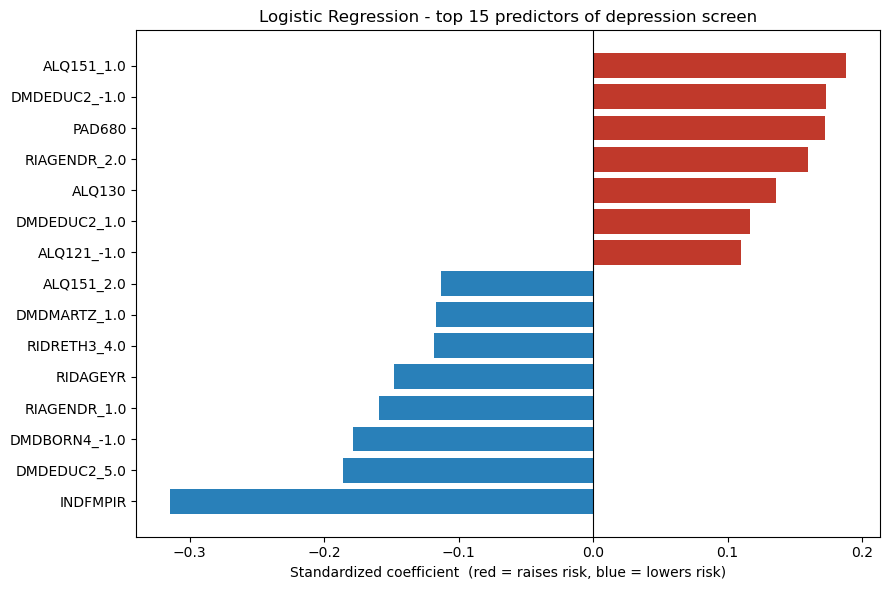

In [9]:
# Plot the 15 strongest coefficients so direction of effect is easy to read
top_coef = coefficients.head(15).sort_values("Coefficient")
colors = ["#c0392b" if v > 0 else "#2980b9" for v in top_coef["Coefficient"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coef["Feature"], top_coef["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized coefficient  (red = raises risk, blue = lowers risk)")
ax.set_title("Logistic Regression - top 15 predictors of depression screen")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "4_1_logistic_coefficients.png"), dpi=150)
plt.show()

### Model B - Random Forest

Uses the **one-hot, unscaled** split. Trees split on thresholds, so scaling adds nothing.

- `class_weight="balanced_subsample"` rebalances inside every bootstrap sample.
- `min_samples_leaf` is the key guard here: with only ~1,020 positive training rows,
  small leaves memorize noise. We tune it on validation.

In [12]:
# Leaf-size and feature-sampling combinations to try
FOREST_GRID = [
    {"min_samples_leaf": 5,  "max_features": "sqrt"},
    {"min_samples_leaf": 10, "max_features": "sqrt"},
    {"min_samples_leaf": 20, "max_features": "sqrt"},
    {"min_samples_leaf": 40, "max_features": "sqrt"},
    {"min_samples_leaf": 20, "max_features": 0.3},
    {"min_samples_leaf": 20, "max_features": 0.6},
]


# Build a Random Forest with the project's fixed settings
def build_forest(min_samples_leaf, max_features):
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


# Fit one forest per grid entry and record its validation PR-AUC
forest_search = []
for params in FOREST_GRID:
    model = build_forest(**params).fit(X_train_tree, y_train)
    metrics = score_model(model, X_val_tree, y_val)
    forest_search.append({**params, **metrics})

forest_search_df = pd.DataFrame(forest_search)
display(forest_search_df.round(4))

# Pick the settings with the best validation PR-AUC
best_forest_params = FOREST_GRID[int(forest_search_df["PR_AUC"].idxmax())]
print(f"\nBest Random Forest settings: {best_forest_params}")

,min_samples_leaf,max_features,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,5,sqrt,0.2388,0.7156,0.1957,0.2893,0.2335,0.8534,0.5
1,10,sqrt,0.2374,0.7175,0.3872,0.2935,0.3339,0.8238,0.5
2,20,sqrt,0.2375,0.7185,0.4979,0.2427,0.3264,0.7655,0.5
3,40,sqrt,0.2378,0.7226,0.5745,0.2231,0.3214,0.7233,0.5
4,20,0.3,0.2437,0.7153,0.4596,0.2512,0.3248,0.7820,0.5
5,20,0.6,0.2353,0.7046,0.4255,0.2604,0.3231,0.7966,0.5



Best Random Forest settings: {'min_samples_leaf': 20, 'max_features': 0.3}


In [13]:
# Refit the winning Random Forest on the training data
forest_model = build_forest(**best_forest_params).fit(X_train_tree, y_train)

# Record its validation performance on the shared scoreboard
forest_val = score_model(forest_model, X_val_tree, y_val)
board.add("RandomForest", "Validation", forest_val)

print("Random Forest - validation")
for k, v in forest_val.items():
    print(f"  {k:<10} {v:.4f}")

Random Forest - validation
  PR_AUC     0.2437
  ROC_AUC    0.7153
  Recall     0.4596
  Precision  0.2512
  F1         0.3248
  Accuracy   0.7820
  Threshold  0.5000


#### Feature importance - permutation, not Gini

The built-in `feature_importances_` is biased toward features with many split points, and
`ALQ121` alone became 11 dummy columns. Permutation importance measured on the **validation**
set answers the honest question: how much does validation performance drop if this one
column is shuffled?

In [14]:
# Measure how much validation PR-AUC falls when each column is randomly shuffled
perm = permutation_importance(
    forest_model,
    X_val_tree,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame({
    "Feature": X_val_tree.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 features by permutation importance")
display(importance.head(15).round(5))

Top 15 features by permutation importance


,Feature,Importance_Mean,Importance_Std
0,INDFMPIR,0.02427,0.00905
1,RIDAGEYR,0.01724,0.00438
2,SLD012,0.01455,0.00406
3,SLD013,0.01330,0.00304
4,ALQ151_1.0,0.01248,0.00260
5,PAD680,0.00935,0.00416
6,RIAGENDR_2.0,0.00725,0.00510
7,RIAGENDR_1.0,0.00714,0.00558
8,ALQ130,0.00559,0.00272
9,DMDMARTZ_1.0,0.00328,0.00392


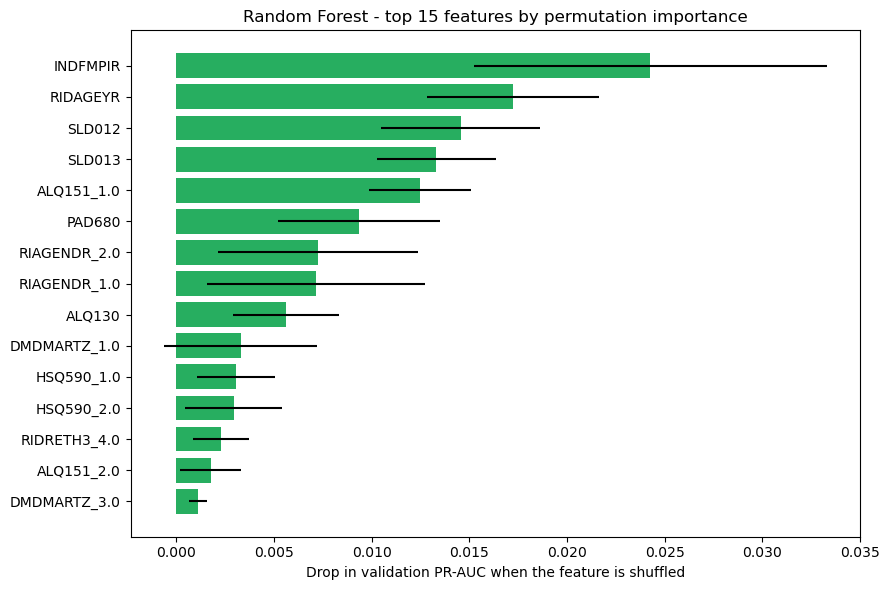

In [15]:
# Plot the 15 most important features
top_importance = importance.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance_Mean"],
    xerr=top_importance["Importance_Std"],
    color="#27ae60",
)
ax.set_xlabel("Drop in validation PR-AUC when the feature is shuffled")
ax.set_title("Random Forest - top 15 features by permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "4_2_forest_permutation_importance.png"), dpi=150)
plt.show()

#### Threshold tuning

The default 0.5 cut-off is arbitrary for imbalanced data. Here we pick the threshold that
maximizes F1 on the validation set, then reuse that exact number on test.

Note for the write-up: in a screening context, recall usually matters more than precision -
missing a depressed respondent is worse than flagging someone for a follow-up question.
The team can swap the objective from F1 to "highest precision at recall >= 0.70" if desired.

In [16]:
# Search the precision-recall curve for the threshold with the best F1 score
def best_f1_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, proba)

    # The curve returns one more precision/recall point than thresholds, so trim the last one
    precision, recall = precision[:-1], recall[:-1]

    # Guard against a zero denominator when precision and recall are both zero
    denominator = np.where((precision + recall) == 0, 1e-9, precision + recall)
    f1_scores = 2 * precision * recall / denominator

    return float(thresholds[int(np.argmax(f1_scores))])

# Tune each model's threshold on validation only
logistic_threshold = best_f1_threshold(logistic_model, X_val_std, y_val)
forest_threshold   = best_f1_threshold(forest_model, X_val_tree, y_val)

print(f"Logistic Regression tuned threshold: {logistic_threshold:.4f}")
print(f"Random Forest       tuned threshold: {forest_threshold:.4f}")

Logistic Regression tuned threshold: 0.6275
Random Forest       tuned threshold: 0.5338


#### Final test evaluation

This is the **only** place the test set is touched. Nothing above this cell used it.

In [17]:
# Score both winning models on the held-out test set using their tuned thresholds
logistic_test = score_model(logistic_model, X_test_std, y_test, threshold=logistic_threshold)
forest_test   = score_model(forest_model, X_test_tree, y_test, threshold=forest_threshold)

board.add("LogisticRegression", "Test", logistic_test)
board.add("RandomForest", "Test", forest_test)

# Show the full comparison table, PR-AUC first because of class imbalance
results = board.to_frame()
display(results.round(4))

,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,LogisticRegression,Test,0.2444,0.6781,0.4255,0.2415,0.3082,0.7820,0.6275
1,RandomForest,Test,0.2327,0.6736,0.3277,0.2232,0.2655,0.7932,0.5338
2,RandomForest,Validation,0.2437,0.7153,0.4596,0.2512,0.3248,0.7820,0.5000
3,LogisticRegression,Validation,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5000


In [18]:
# Print a confusion matrix and full classification report for each model
def report_model(name, model, X, y, threshold):
    pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    print(f"\n{'=' * 60}\n{name} - test set (threshold {threshold:.3f})\n{'=' * 60}")
    print(pd.DataFrame(
        confusion_matrix(y, pred),
        index=["Actual: No", "Actual: Yes"],
        columns=["Pred: No", "Pred: Yes"],
    ))
    print()
    print(classification_report(y, pred, target_names=["No depression", "Depression"], digits=3))


report_model("Logistic Regression", logistic_model, X_test_std, y_test, logistic_threshold)
report_model("Random Forest", forest_model, X_test_tree, y_test, forest_threshold)


Logistic Regression - test set (threshold 0.627)
             Pred: No  Pred: Yes
Actual: No       1511        314
Actual: Yes       135        100

               precision    recall  f1-score   support

No depression      0.918     0.828     0.871      1825
   Depression      0.242     0.426     0.308       235

     accuracy                          0.782      2060
    macro avg      0.580     0.627     0.589      2060
 weighted avg      0.841     0.782     0.806      2060


Random Forest - test set (threshold 0.534)
             Pred: No  Pred: Yes
Actual: No       1557        268
Actual: Yes       158         77

               precision    recall  f1-score   support

No depression      0.908     0.853     0.880      1825
   Depression      0.223     0.328     0.266       235

     accuracy                          0.793      2060
    macro avg      0.566     0.590     0.573      2060
 weighted avg      0.830     0.793     0.810      2060



#### Save models and results

The scoreboard CSV is shared. When the CatBoost, XGBoost and SVM notebooks call
`Scoreboard.save(SCOREBOARD_CSV)`, their rows are appended to the same table and the
final report can read one file.

In [19]:
# Persist both fitted models with their tuned thresholds and column order
joblib.dump(
    {"model": logistic_model, "threshold": logistic_threshold, "columns": list(X_train_std.columns), "C": best_C},
    os.path.join(MODEL_DIR, "logistic_seed42.joblib"),
)

joblib.dump(
    {"model": forest_model, "threshold": forest_threshold, "columns": list(X_train_tree.columns), "params": best_forest_params},
    os.path.join(MODEL_DIR, "random_forest_seed42.joblib"),
)

# Write the shared scoreboard
final_board = board.save(SCOREBOARD_CSV)

# Save the interpretation tables for the written report
coefficients.to_csv(os.path.join(MODEL_DIR, "logistic_coefficients.csv"), index=False)
importance.to_csv(os.path.join(MODEL_DIR, "random_forest_permutation_importance.csv"), index=False)

print("Saved:")
print(f"  {MODEL_DIR}/logistic_seed42.joblib")
print(f"  {MODEL_DIR}/random_forest_seed42.joblib")
print(f"  {SCOREBOARD_CSV}")
display(final_board.round(4))

Saved:
  .\Models/logistic_seed42.joblib
  .\Models/random_forest_seed42.joblib
  .\Models\rf_logreg_models_scoreboard.csv


,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,SVM,Test,0.2580,0.6795,0.4638,0.2577,0.3313,0.7864,0.1706
1,SVM,Validation,0.2749,0.7544,0.0213,0.2083,0.0386,0.8791,0.5000
2,LogisticRegression,Test,0.2444,0.6781,0.4255,0.2415,0.3082,0.7820,0.6275
3,RandomForest,Test,0.2327,0.6736,0.3277,0.2232,0.2655,0.7932,0.5338
4,RandomForest,Validation,0.2437,0.7153,0.4596,0.2512,0.3248,0.7820,0.5000
5,LogisticRegression,Validation,0.2342,0.7041,0.6426,0.1979,0.3026,0.6621,0.5000


#### Notes for next

1. Same splits, same `RANDOM_STATE = 42`, no re-splitting.
2. Same `DROP_EXACT` / `DROP_PREFIX` clean-up applied to their own encoding.
3. Same class-imbalance handling (`class_weight="balanced"`, or `scale_pos_weight ~ 8.4`
   for XGBoost, or `auto_class_weights="Balanced"` for CatBoost).
4. Tune on validation, touch test once.
5. Call `score_model()` and `Scoreboard.save(SCOREBOARD_CSV)` so all rows land in one table.